# Data summary
Basic description and summary statistics for `trend_model_index_prices_cleaned.xlsx`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

file_path = '/Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/data/trend_model_index_prices_cleaned.xlsx'
df = pd.read_excel(file_path)
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.sort_values('Dates').reset_index(drop=True)

assets = [c for c in df.columns if c != 'Dates']
df.head()

,Dates,USDBRL Curncy,B1MLBRUS Index,AUDUSD Curncy,B1MLAUUS Index,BCOM Index,XAU Curncy
0,2002-01-01,2.310500,98.395200,0.509700,74.453000,89.033300,278.950000
1,2002-01-02,2.302000,98.730500,0.514800,75.128500,89.883500,278.750000
2,2002-01-03,2.295000,99.262600,0.515500,75.099800,89.625900,278.450000
3,2002-01-04,2.331000,97.695700,0.520700,75.964400,91.446400,278.950000
4,2002-01-07,2.327000,98.035900,0.518300,75.722000,92.361700,278.750000


## Structure

In [2]:
basic = pd.DataFrame({
    'item': ['rows', 'columns', 'assets', 'start_date', 'end_date', 'duplicate_dates', 'all_missing_values'],
    'value': [
        len(df),
        len(df.columns),
        len(assets),
        df['Dates'].min().date(),
        df['Dates'].max().date(),
        int(df['Dates'].duplicated().sum()),
        int(df.isna().sum().sum())
    ]
})
basic

,item,value
0,rows,6340
1,columns,7
2,assets,6
3,start_date,2002-01-01
4,end_date,2026-04-20
5,duplicate_dates,0
6,all_missing_values,0


In [3]:
missing = df.isna().sum().rename('missing_count').to_frame()
missing['missing_pct'] = missing['missing_count'] / len(df)
missing

,missing_count,missing_pct
Dates,0,0.000000
USDBRL Curncy,0,0.000000
B1MLBRUS Index,0,0.000000
AUDUSD Curncy,0,0.000000
B1MLAUUS Index,0,0.000000
BCOM Index,0,0.000000
XAU Curncy,0,0.000000


In [4]:
df[assets].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6340 entries, 0 to 6339
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   USDBRL Curncy   6340 non-null   float64
 1   B1MLBRUS Index  6340 non-null   float64
 2   AUDUSD Curncy   6340 non-null   float64
 3   B1MLAUUS Index  6340 non-null   float64
 4   BCOM Index      6340 non-null   float64
 5   XAU Curncy      6340 non-null   float64
dtypes: float64(6)
memory usage: 297.3 KB


## Price level summary

In [5]:
price_stats = df[assets].describe().T
price_stats['median'] = df[assets].median()
price_stats['skew'] = df[assets].skew()
price_stats['kurtosis'] = df[assets].kurtosis()
price_stats = price_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'median', 'skew', 'kurtosis']]
price_stats

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
USDBRL Curncy,"6,340.000000",3.296085,1.346655,1.539100,2.138075,3.002850,4.697225,6.293100,3.002850,0.512253,-1.135485
B1MLBRUS Index,"6,340.000000",245.849240,75.454729,63.085500,210.437350,262.708450,300.706825,385.005200,262.708450,-0.797506,-0.180505
AUDUSD Curncy,"6,340.000000",0.774282,0.128203,0.506900,0.685300,0.749350,0.861475,1.102000,0.749350,0.629582,-0.240916
B1MLAUUS Index,"6,340.000000",152.172406,30.824254,73.980900,134.219925,153.670000,168.918425,216.979300,153.670000,-0.203642,-0.051210
BCOM Index,"6,340.000000",120.330048,33.386336,59.479500,93.241375,115.426300,143.468650,237.953100,115.426300,0.586141,-0.189364
XAU Curncy,"6,340.000000","1,347.948068",807.793170,278.450000,802.300000,"1,274.660000","1,725.070000","5,417.210000","1,274.660000",1.650700,4.581407


In [6]:
latest = pd.DataFrame({
    'latest_date': [df['Dates'].max().date()] * len(assets),
    'latest_price': df.loc[df.index[-1], assets].values
}, index=assets)
latest

,latest_date,latest_price
USDBRL Curncy,2026-04-20,4.982700
B1MLBRUS Index,2026-04-20,322.183100
AUDUSD Curncy,2026-04-20,0.717400
B1MLAUUS Index,2026-04-20,152.156500
BCOM Index,2026-04-20,133.131700
XAU Curncy,2026-04-20,"4,804.790000"


## Price series

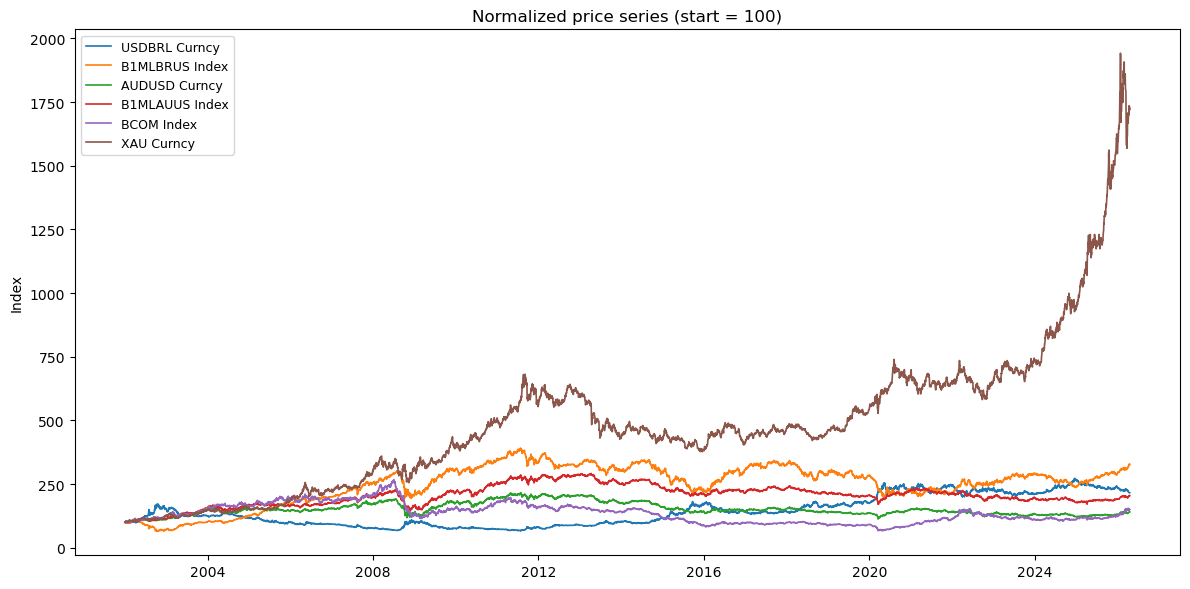

In [7]:
price_indexed = df.set_index('Dates')[assets]
price_norm = price_indexed / price_indexed.iloc[0] * 100

plt.figure(figsize=(12, 6))
for c in assets:
    plt.plot(price_norm.index, price_norm[c], label=c, linewidth=1.2)
plt.title('Normalized price series (start = 100)')
plt.xlabel('')
plt.ylabel('Index')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## Daily return summary

In [8]:
ret = price_indexed.pct_change().dropna()

ret_stats = pd.DataFrame(index=assets)
ret_stats['mean_daily'] = ret.mean()
ret_stats['std_daily'] = ret.std()
ret_stats['min_daily'] = ret.min()
ret_stats['max_daily'] = ret.max()
ret_stats['skew'] = ret.skew()
ret_stats['kurtosis'] = ret.kurtosis()
ret_stats['annual_return_252'] = ret_stats['mean_daily'] * 252
ret_stats['annual_vol_252'] = ret_stats['std_daily'] * np.sqrt(252)
ret_stats['sharpe_0rf'] = ret_stats['annual_return_252'] / ret_stats['annual_vol_252']
ret_stats

,mean_daily,std_daily,min_daily,max_daily,skew,kurtosis,annual_return_252,annual_vol_252,sharpe_0rf
USDBRL Curncy,0.000175,0.010329,-0.098266,0.073706,0.235840,5.485994,0.043975,0.163969,0.268193
B1MLBRUS Index,0.000238,0.010045,-0.079685,0.126236,0.070022,9.295024,0.059867,0.159457,0.375445
AUDUSD Curncy,0.000082,0.007540,-0.070341,0.086287,-0.244221,9.866013,0.020762,0.119698,0.173454
B1MLAUUS Index,0.000142,0.007577,-0.084136,0.068334,-0.635163,11.203935,0.035673,0.120280,0.296583
BCOM Index,0.000114,0.010073,-0.062017,0.058100,-0.279478,2.896832,0.028802,0.159896,0.180130
XAU Curncy,0.000508,0.010866,-0.090737,0.107883,-0.312925,6.027763,0.128085,0.172486,0.742583


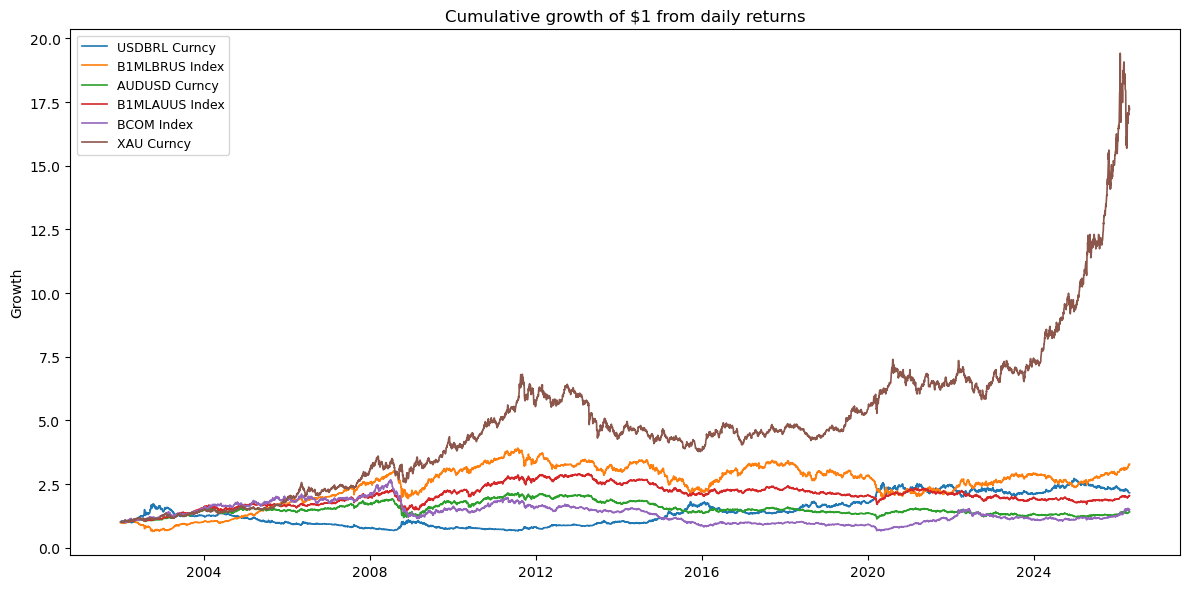

In [9]:
plt.figure(figsize=(12, 6))
for c in assets:
    plt.plot((1 + ret[c]).cumprod(), label=c, linewidth=1.2)
plt.title('Cumulative growth of $1 from daily returns')
plt.xlabel('')
plt.ylabel('Growth')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## Correlation

In [10]:
corr = ret.corr()
corr

,USDBRL Curncy,B1MLBRUS Index,AUDUSD Curncy,B1MLAUUS Index,BCOM Index,XAU Curncy
USDBRL Curncy,1.000000,-0.709144,-0.416234,-0.271363,-0.285310,-0.143170
B1MLBRUS Index,-0.709144,1.000000,0.376361,0.410023,0.299073,0.134097
AUDUSD Curncy,-0.416234,0.376361,1.000000,0.776617,0.420106,0.360862
B1MLAUUS Index,-0.271363,0.410023,0.776617,1.000000,0.408638,0.316043
BCOM Index,-0.285310,0.299073,0.420106,0.408638,1.000000,0.413795
XAU Curncy,-0.143170,0.134097,0.360862,0.316043,0.413795,1.000000


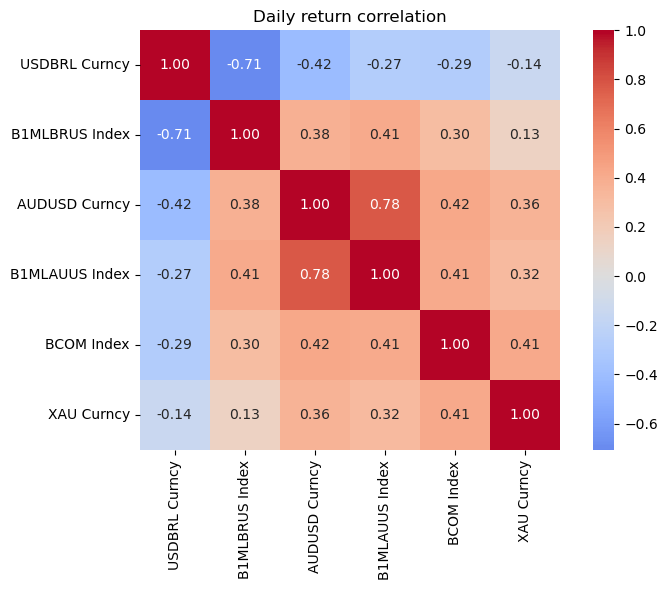

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Daily return correlation')
plt.tight_layout()
plt.show()

## Rolling volatility

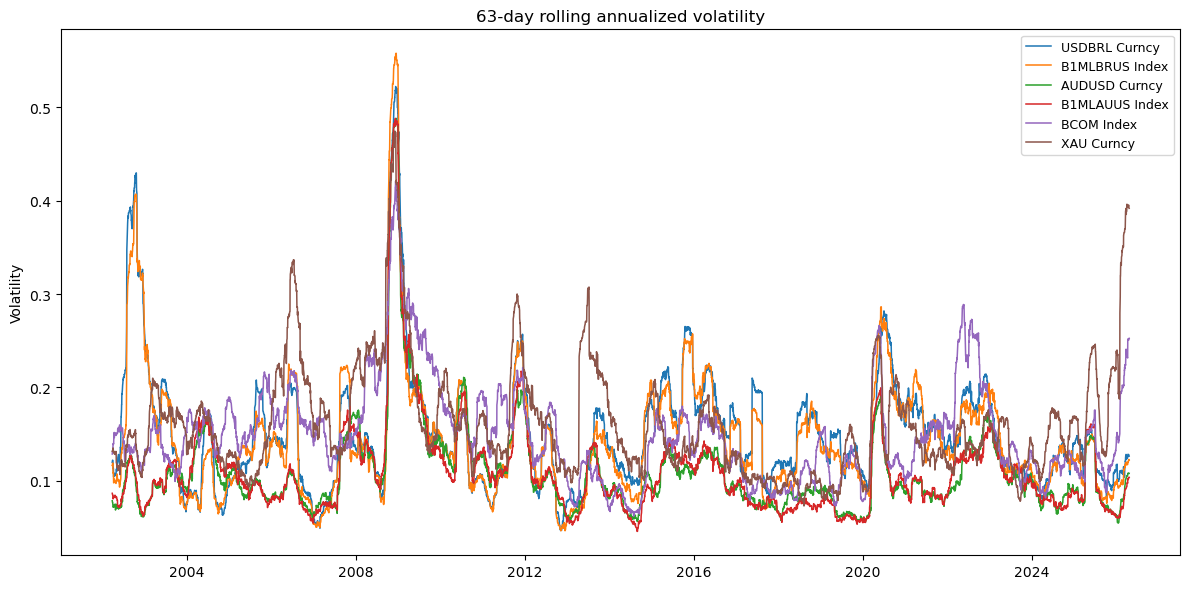

In [12]:
roll_vol = ret.rolling(63).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
for c in assets:
    plt.plot(roll_vol.index, roll_vol[c], label=c, linewidth=1.1)
plt.title('63-day rolling annualized volatility')
plt.xlabel('')
plt.ylabel('Volatility')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## Summary

In [13]:
summary = pd.DataFrame({
    'first_obs': price_indexed.iloc[0],
    'last_obs': price_indexed.iloc[-1],
    'total_return': price_indexed.iloc[-1] / price_indexed.iloc[0] - 1,
    'best_day': ret.max(),
    'worst_day': ret.min()
})
summary

,first_obs,last_obs,total_return,best_day,worst_day
USDBRL Curncy,2.310500,4.982700,1.156546,0.073706,-0.098266
B1MLBRUS Index,98.395200,322.183100,2.274378,0.126236,-0.079685
AUDUSD Curncy,0.509700,0.717400,0.407495,0.086287,-0.070341
B1MLAUUS Index,74.453000,152.156500,1.043658,0.068334,-0.084136
BCOM Index,89.033300,133.131700,0.495302,0.058100,-0.062017
XAU Curncy,278.950000,"4,804.790000",16.224556,0.107883,-0.090737
